In [59]:
#Importacion de librerias necesarias para el proyecto
import pandas as pd
import numpy as np
import requests
import json
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, precision_score, recall_score, 
                             f1_score, roc_auc_score, confusion_matrix,
                             classification_report)

# Librerías para visualización
from IPython.display import display, clear_output
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Configuración de estilo
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12

## Carga y limpieza de datos

### Extracion de data, y eliminacion de columnas no deseadas

In [60]:

#  Cargar JSON
df = pd.read_json('TelecomX_Data.json')
#df.head()

# Expandir cada columna anidada
customer_expanded = pd.json_normalize(df['customer'])
phone_expanded = pd.json_normalize(df['phone'])
internet_expanded = pd.json_normalize(df['internet'])
account_expanded = pd.json_normalize(df['account'])

# Combinar todo 
df_final = pd.concat([
    df[['customerID', 'Churn']],
    customer_expanded,
    phone_expanded,
    internet_expanded,
    account_expanded
], axis=1)

df_final.head()

,customerID,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,...,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Charges.Monthly,Charges.Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.600,593.3
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.900,542.4
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.900,280.85
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.000,1237.85
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.900,267.4


In [61]:
# Verificar si 'charges' está anidado y expandirlo
if 'charges' in df_final.columns:
    charges_expanded = pd.json_normalize(df_final['charges'])
    df_final = pd.concat([df_final.drop('charges', axis=1), charges_expanded], axis=1)
  
df = df_final  

### Tranfsformacion y Encoding de la data

In [62]:
#  ELIMINAR CUSTOMERID (irrelevante)
df = df.drop('customerID', axis=1)


# LIMPIAR CHURN (eliminar filas con valor vacío)
filas_iniciales = len(df)
df = df[df['Churn'] != ''].copy()

#  LIMPIAR Y RELLENAR CHARGES.TOTAL
# Convertir a numérico (los espacios ' ' se vuelven NaN)
df['Charges.Total'] = pd.to_numeric(df['Charges.Total'], errors='coerce')
nan_count = df['Charges.Total'].isna().sum()
# Rellenar NaN con 0 (clientes nuevos)
df['Charges.Total'] = df['Charges.Total'].fillna(0)


#  TRANSFORMAR VARIABLES BINARIAS (Yes/No → 1/0)
binary_cols = ['Partner', 'Dependents', 'PhoneService', 'PaperlessBilling']
for col in binary_cols:
    df[col] = df[col].map({'Yes': 1, 'No': 0})


#  TRANSFORMAR GENDER (Female/Male → 1/0)
df['gender'] = df['gender'].map({'Female': 1, 'Male': 0})


#  TRANSFORMAR MULTIPLELINES (One-Hot Encoding)
multiple_dummies = pd.get_dummies(df['MultipleLines'], prefix='MultipleLines', drop_first=True)
df = pd.concat([df, multiple_dummies], axis=1)
df = df.drop('MultipleLines', axis=1)


# TRANSFORMAR INTERNETSERVICE (One-Hot Encoding)
internet_dummies = pd.get_dummies(df['InternetService'], prefix='InternetService', drop_first=True)
df = pd.concat([df, internet_dummies], axis=1)
df = df.drop('InternetService', axis=1)

# TRANSFORMAR SERVICIOS DE INTERNET
internet_services = ['OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 
                     'TechSupport', 'StreamingTV', 'StreamingMovies']

for service in internet_services:
    dummies = pd.get_dummies(df[service], prefix=service, drop_first=True)
    df = pd.concat([df, dummies], axis=1)
    df = df.drop(service, axis=1)


# TRANSFORMAR CONTRACT (One-Hot Encoding)
contract_dummies = pd.get_dummies(df['Contract'], prefix='Contract', drop_first=True)
df = pd.concat([df, contract_dummies], axis=1)
df = df.drop('Contract', axis=1)


# TRANSFORMAR PAYMENTMETHOD (One-Hot Encoding)
payment_dummies = pd.get_dummies(df['PaymentMethod'], prefix='PaymentMethod', drop_first=True)
df = pd.concat([df, payment_dummies], axis=1)
df = df.drop('PaymentMethod', axis=1)


# TRANSFORMAR CHURN (variable objetivo)
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})


### Verificacion de la proporcion de cancelacion

In [63]:
# Calcular la proporción de cancelación
churn_proportion = df['Churn'].value_counts(normalize=True) * 100

# Mostrar resultados de forma clara
print(" PROPORCIÓN DE CANCELACIÓN (CHURN):")
print("-" * 40)
print(churn_proportion)
print("-" * 40)

# También podemos ver los conteos absolutos
churn_counts = df['Churn'].value_counts()
print("\n CONTEO ABSOLUTO:")
print(f"Clientes activos (0): {churn_counts[0]}")
print(f"Clientes cancelados (1): {churn_counts[1]}")

 PROPORCIÓN DE CANCELACIÓN (CHURN):
----------------------------------------
Churn
0   73.463
1   26.537
Name: proportion, dtype: float64
----------------------------------------

 CONTEO ABSOLUTO:
Clientes activos (0): 5174
Clientes cancelados (1): 1869


### Correlacion

In [64]:
# PREPARAR DATOS
# Asegurarnos que todas las columnas sean numéricas
df_numerico = df.select_dtypes(include=[np.number])

print(f"\n Dimensiones del dataset numérico: {df_numerico.shape}")
print(f"\n Columnas incluidas ({len(df_numerico.columns)}):")
for i, col in enumerate(df_numerico.columns[:10]):  # Mostrar primeras 10
    print(f"   {i+1}. {col}")
if len(df_numerico.columns) > 10:
    print(f"   ... y {len(df_numerico.columns) - 10} más")


 Dimensiones del dataset numérico: (7043, 10)

 Columnas incluidas (10):
   1. Churn
   2. gender
   3. SeniorCitizen
   4. Partner
   5. Dependents
   6. tenure
   7. PhoneService
   8. PaperlessBilling
   9. Charges.Monthly
   10. Charges.Total


<Axes: >

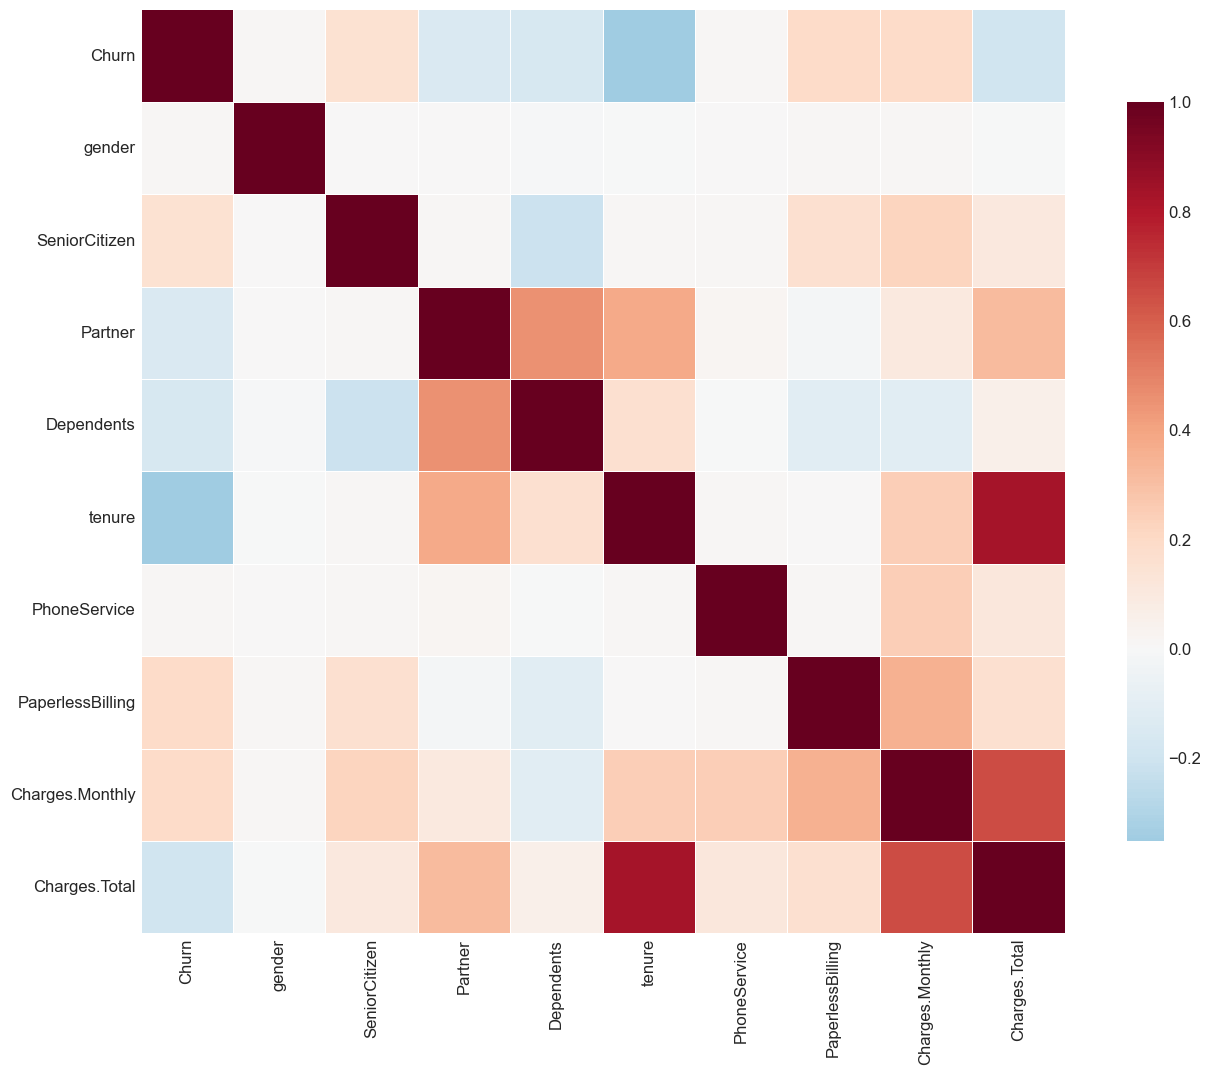

In [65]:
# CALCULAR MATRIZ DE CORRELACIÓN

correlation_matrix = df_numerico.corr()

#  VISUALIZAR MATRIZ COMPLETA (MAPA DE CALOR)

plt.figure(figsize=(16, 12))
sns.heatmap(correlation_matrix, 
            annot=False,  # Cambiar a True si quieres ver números
            cmap='RdBu_r', 
            center=0,
            square=True,
            linewidths=0.5,
            cbar_kws={"shrink": 0.8})

In [66]:

# ENFOQUE EN CORRELACIÓN CON CHURN 

print("\n" + "=" * 70)
print(" CORRELACIÓN CON LA VARIABLE OBJETIVO (CHURN)")
print("=" * 70)

# Obtener correlaciones con Churn y ordenarlas
corr_con_churn = correlation_matrix['Churn'].drop('Churn').sort_values(ascending=False)

# Convertir a DataFrame para mejor visualización
df_corr_churn = pd.DataFrame({
    'Variable': corr_con_churn.index,
    'Correlación con Churn': corr_con_churn.values,
    '|Correlación|': np.abs(corr_con_churn.values)
}).sort_values('|Correlación|', ascending=False)

print("\n TOP 15 VARIABLES MÁS CORRELACIONADAS CON CHURN:")
print("-" * 70)
print(df_corr_churn.head(15).to_string(index=False))



 CORRELACIÓN CON LA VARIABLE OBJETIVO (CHURN)

 TOP 15 VARIABLES MÁS CORRELACIONADAS CON CHURN:
----------------------------------------------------------------------
        Variable  Correlación con Churn  |Correlación|
          tenure                 -0.352          0.352
   Charges.Total                 -0.198          0.198
 Charges.Monthly                  0.193          0.193
PaperlessBilling                  0.192          0.192
      Dependents                 -0.164          0.164
   SeniorCitizen                  0.151          0.151
         Partner                 -0.150          0.150
    PhoneService                  0.012          0.012
          gender                  0.009          0.009


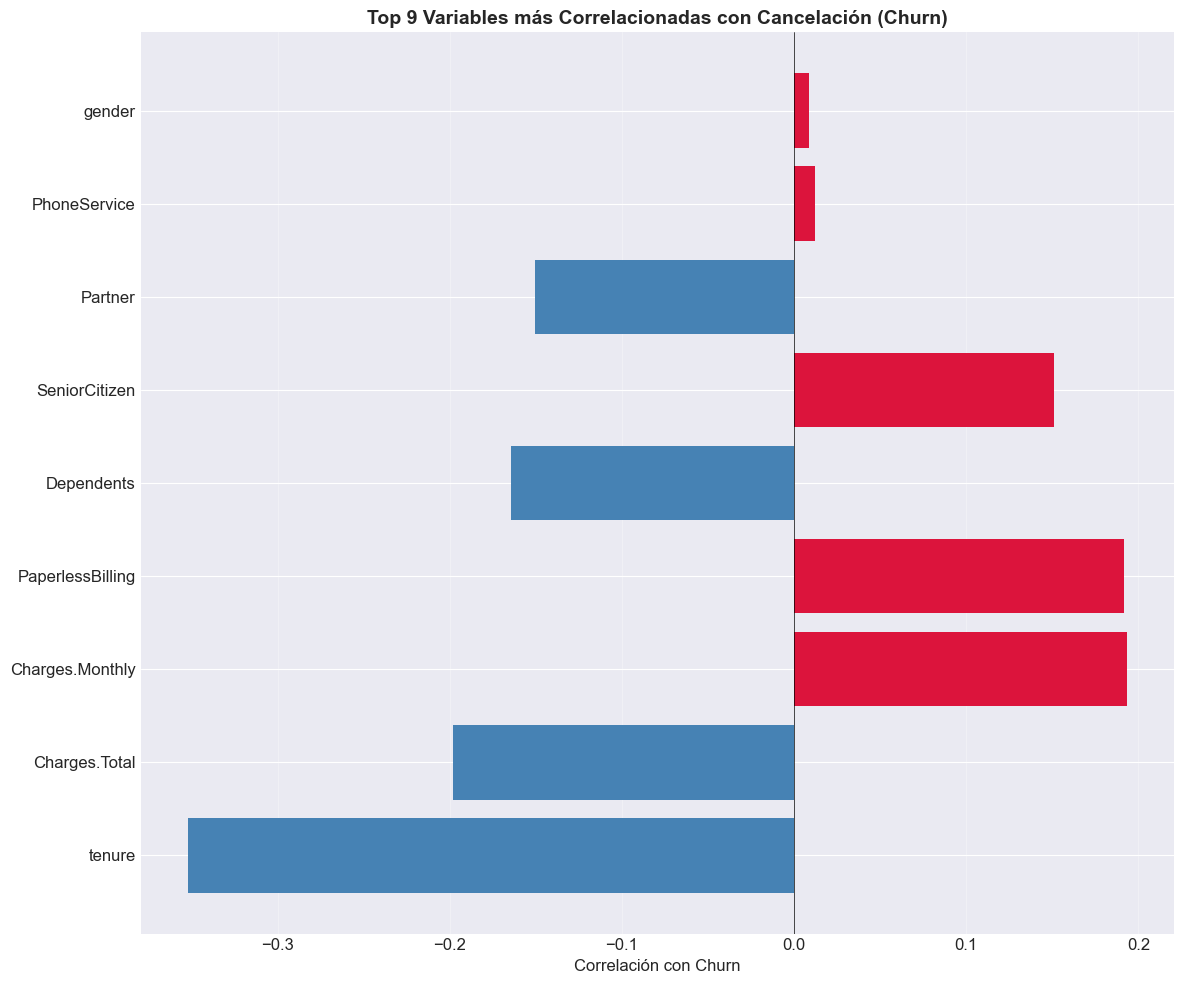

In [67]:
# VISUALIZACIÓN GRÁFICA DE CORRELACIONES CON CHURN

plt.figure(figsize=(12, 10))

# Seleccionar top 20 variables (o todas si hay menos)
top_n = min(20, len(df_corr_churn))
top_corr = df_corr_churn.head(top_n)

# Crear barras horizontales
colors = ['crimson' if x > 0 else 'steelblue' for x in top_corr['Correlación con Churn']]
plt.barh(range(top_n), top_corr['Correlación con Churn'], color=colors)
plt.yticks(range(top_n), top_corr['Variable'])
plt.xlabel('Correlación con Churn', fontsize=12)
plt.title(f'Top {top_n} Variables más Correlacionadas con Cancelación (Churn)', fontsize=14, fontweight='bold')
plt.axvline(x=0, color='black', linestyle='-', linewidth=0.5)
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

In [68]:

# ANÁLISIS DE MULTICOLINEALIDAD (VARIABLES REDUNDANTES)

print("\n" + "=" * 70)
print("ANÁLISIS DE MULTICOLINEALIDAD (VARIABLES REDUNDANTES)")
print("=" * 70)

# Encontrar pares con alta correlación (> 0.7)
high_corr_pairs = []
threshold = 0.7

for i in range(len(correlation_matrix.columns)):
    for j in range(i+1, len(correlation_matrix.columns)):
        if abs(correlation_matrix.iloc[i, j]) > threshold:
            high_corr_pairs.append({
                'Variable 1': correlation_matrix.columns[i],
                'Variable 2': correlation_matrix.columns[j],
                'Correlación': correlation_matrix.iloc[i, j]
            })

if high_corr_pairs:
    df_high_corr = pd.DataFrame(high_corr_pairs).sort_values('Correlación', ascending=False)
    print(f"\n PARES CON ALTA CORRELACIÓN (> {threshold}):")
    print("-" * 70)
    print(df_high_corr.to_string(index=False))
    
    # Análisis de posibles redundancias
    print("\n RECOMENDACIONES:")
    print("   - Considerar eliminar una variable de cada par redundante")
    print("   - Priorizar mantener la variable con mayor correlación con Churn")
    print("   - Técnicas como PCA pueden ayudar si hay mucha redundancia")
else:
    print(f"\n No se encontraron pares con correlación > {threshold}")




ANÁLISIS DE MULTICOLINEALIDAD (VARIABLES REDUNDANTES)

 PARES CON ALTA CORRELACIÓN (> 0.7):
----------------------------------------------------------------------
Variable 1    Variable 2  Correlación
    tenure Charges.Total        0.826

 RECOMENDACIONES:
   - Considerar eliminar una variable de cada par redundante
   - Priorizar mantener la variable con mayor correlación con Churn
   - Técnicas como PCA pueden ayudar si hay mucha redundancia


In [69]:

#  ANÁLISIS ESPECÍFICO DE VARIABLES CLAVE

print("\n" + "=" * 70)
print("🔍 ANÁLISIS DETALLADO DE VARIABLES CLAVE")
print("=" * 70)

# Identificar variables con mayor correlación positiva y negativa
top_positivas = corr_con_churn.head(5)
top_negativas = corr_con_churn.tail(5)

print("\n TOP 5 VARIABLES CON CORRELACIÓN POSITIVA (AUMENTAN CHURN):")
for var, corr in top_positivas.items():
    print(f"   ✅ {var}: +{corr:.3f}")

print("\nTOP 5 VARIABLES CON CORRELACIÓN NEGATIVA (DISMINUYEN CHURN):")
for var, corr in top_negativas.items():
    print(f"   ❌ {var}: {corr:.3f}")


🔍 ANÁLISIS DETALLADO DE VARIABLES CLAVE

 TOP 5 VARIABLES CON CORRELACIÓN POSITIVA (AUMENTAN CHURN):
   ✅ Charges.Monthly: +0.193
   ✅ PaperlessBilling: +0.192
   ✅ SeniorCitizen: +0.151
   ✅ PhoneService: +0.012
   ✅ gender: +0.009

TOP 5 VARIABLES CON CORRELACIÓN NEGATIVA (DISMINUYEN CHURN):
   ❌ gender: 0.009
   ❌ Partner: -0.150
   ❌ Dependents: -0.164
   ❌ Charges.Total: -0.198
   ❌ tenure: -0.352


### Analisis Dirigido

----------------------------------------------------------------------
RELACIÓN: TIEMPO DE CONTRATO × CANCELACIÓN
----------------------------------------------------------------------


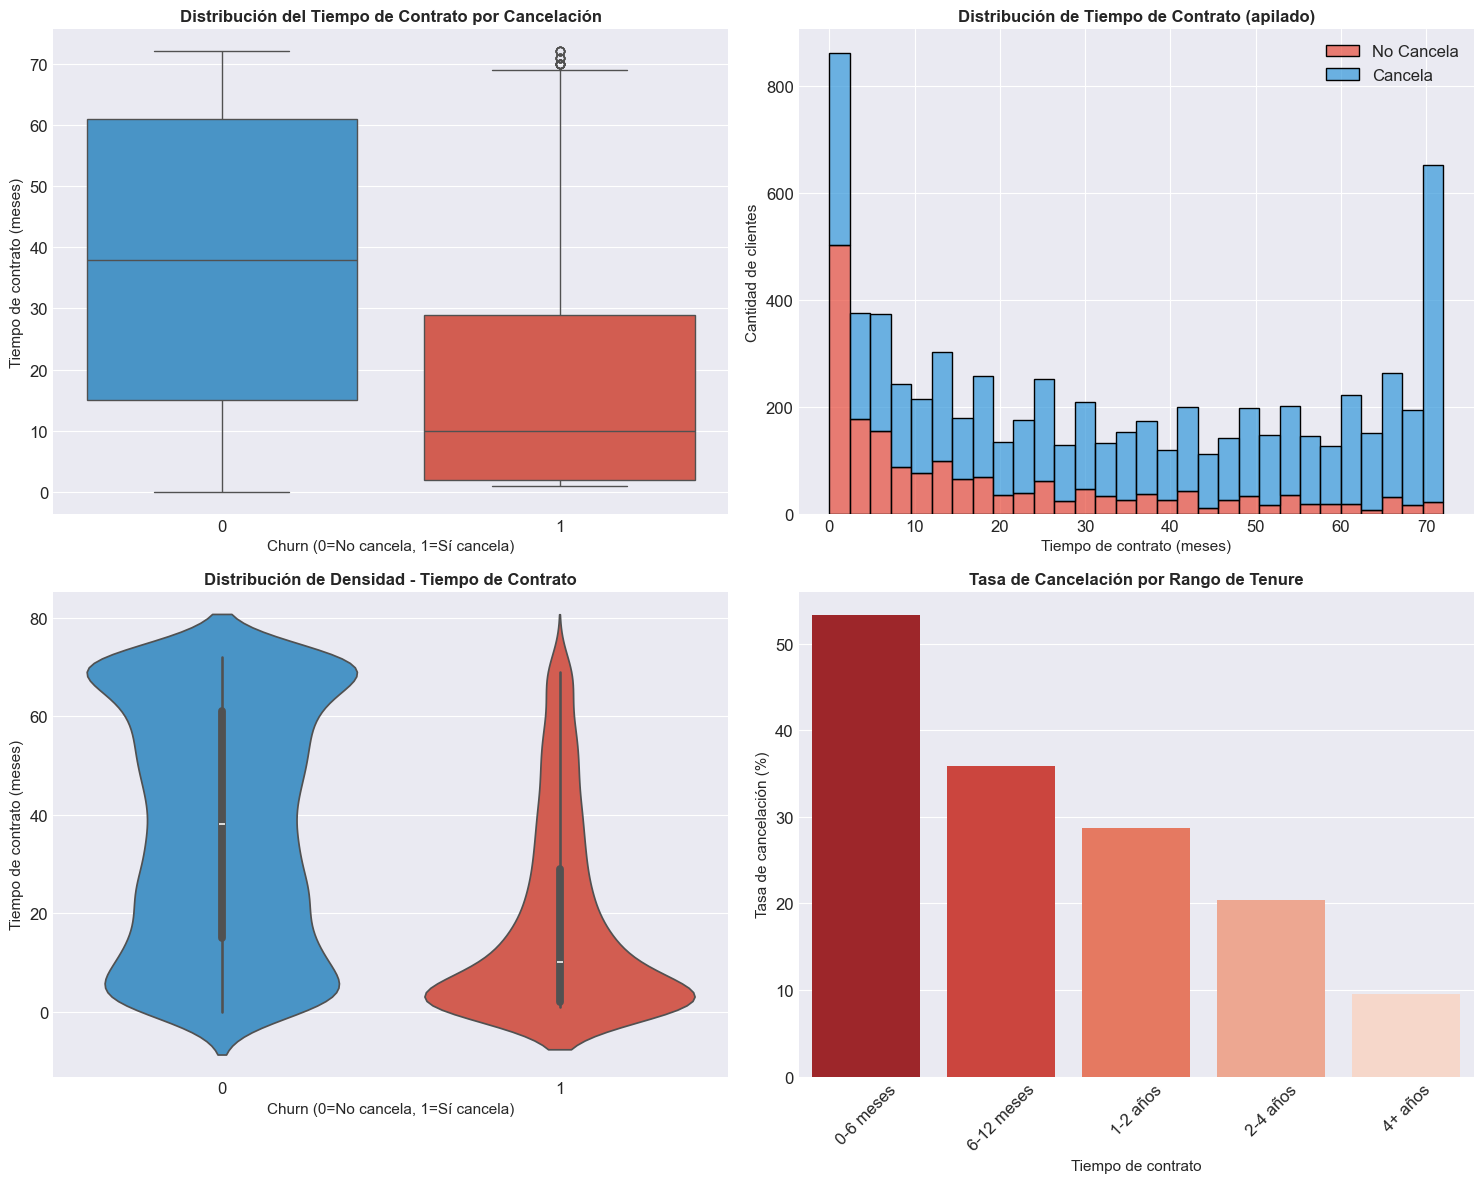

In [70]:

#  TIEMPO DE CONTRATO (TENURE) VS CANCELACIÓN
print("-" * 70)
print("RELACIÓN: TIEMPO DE CONTRATO × CANCELACIÓN")
print("-" * 70)

fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# Gráfico 1: Boxplot de tenure por Churn
ax1 = axes[0, 0]
sns.boxplot(x='Churn', y='tenure', data=df, ax=ax1, palette=['#3498db', '#e74c3c'])
ax1.set_xlabel('Churn (0=No cancela, 1=Sí cancela)', fontsize=11)
ax1.set_ylabel('Tiempo de contrato (meses)', fontsize=11)
ax1.set_title('Distribución del Tiempo de Contrato por Cancelación', fontsize=12, fontweight='bold')

# Gráfico 2: Histograma superpuesto
ax2 = axes[0, 1]
sns.histplot(data=df, x='tenure', hue='Churn', multiple='stack', 
             palette=['#3498db', '#e74c3c'], alpha=0.7, ax=ax2, bins=30)
ax2.set_xlabel('Tiempo de contrato (meses)', fontsize=11)
ax2.set_ylabel('Cantidad de clientes', fontsize=11)
ax2.set_title('Distribución de Tiempo de Contrato (apilado)', fontsize=12, fontweight='bold')
ax2.legend(['No Cancela', 'Cancela'])

# Gráfico 3: Violin plot
ax3 = axes[1, 0]
sns.violinplot(x='Churn', y='tenure', data=df, ax=ax3, palette=['#3498db', '#e74c3c'])
ax3.set_xlabel('Churn (0=No cancela, 1=Sí cancela)', fontsize=11)
ax3.set_ylabel('Tiempo de contrato (meses)', fontsize=11)
ax3.set_title('Distribución de Densidad - Tiempo de Contrato', fontsize=12, fontweight='bold')

# Gráfico 4: Tasa de churn por rangos de tenure (CORREGIDO)
ax4 = axes[1, 1]

# Crear rangos de tenure
df['tenure_range'] = pd.cut(df['tenure'], bins=[0, 6, 12, 24, 48, 72], 
                             labels=['0-6 meses', '6-12 meses', '1-2 años', '2-4 años', '4+ años'])

# Calcular tasa de churn por rango (CORREGIDO: no multiplicamos el DataFrame completo)
churn_by_tenure = df.groupby('tenure_range')['Churn'].mean().reset_index()
churn_by_tenure['Churn'] = churn_by_tenure['Churn'] * 100  # Multiplicamos solo la columna numérica

sns.barplot(x='tenure_range', y='Churn', data=churn_by_tenure, ax=ax4, palette='Reds_r')
ax4.set_xlabel('Tiempo de contrato', fontsize=11)
ax4.set_ylabel('Tasa de cancelación (%)', fontsize=11)
ax4.set_title('Tasa de Cancelación por Rango de Tenure', fontsize=12, fontweight='bold')
ax4.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()




 RELACIÓN: GASTO TOTAL × CANCELACIÓN
----------------------------------------------------------------------


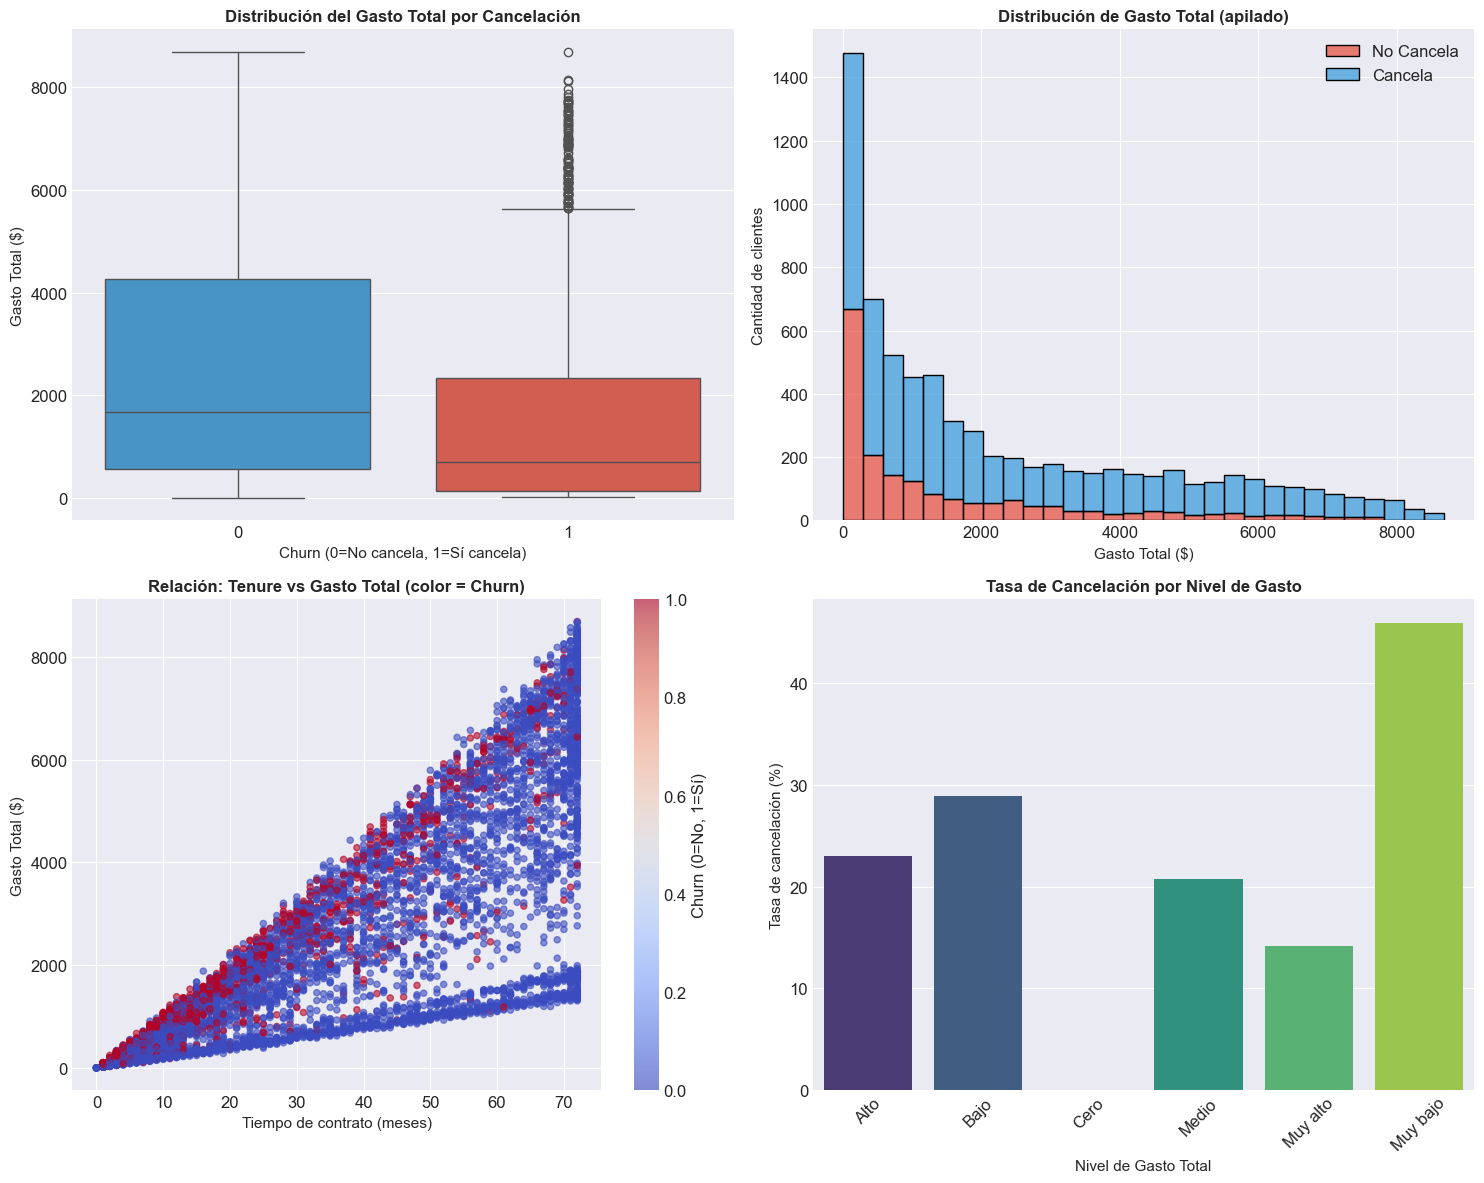

In [71]:

# GASTO TOTAL (CHARGES.TOTAL) VS CANCELACIÓN

print("\n" + "=" * 70)
print(" RELACIÓN: GASTO TOTAL × CANCELACIÓN")
print("-" * 70)

fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# Gráfico 1: Boxplot de Charges.Total por Churn
ax1 = axes[0, 0]
sns.boxplot(x='Churn', y='Charges.Total', data=df, ax=ax1, palette=['#3498db', '#e74c3c'])
ax1.set_xlabel('Churn (0=No cancela, 1=Sí cancela)', fontsize=11)
ax1.set_ylabel('Gasto Total ($)', fontsize=11)
ax1.set_title('Distribución del Gasto Total por Cancelación', fontsize=12, fontweight='bold')

# Gráfico 2: Histograma superpuesto
ax2 = axes[0, 1]
sns.histplot(data=df, x='Charges.Total', hue='Churn', multiple='stack',
             palette=['#3498db', '#e74c3c'], alpha=0.7, ax=ax2, bins=30)
ax2.set_xlabel('Gasto Total ($)', fontsize=11)
ax2.set_ylabel('Cantidad de clientes', fontsize=11)
ax2.set_title('Distribución de Gasto Total (apilado)', fontsize=12, fontweight='bold')
ax2.legend(['No Cancela', 'Cancela'])

# Gráfico 3: Scatter plot tenure vs charges.total coloreado por churn
ax3 = axes[1, 0]
scatter = ax3.scatter(df['tenure'], df['Charges.Total'], 
                      c=df['Churn'], cmap='coolwarm', alpha=0.6, s=20)
ax3.set_xlabel('Tiempo de contrato (meses)', fontsize=11)
ax3.set_ylabel('Gasto Total ($)', fontsize=11)
ax3.set_title('Relación: Tenure vs Gasto Total (color = Churn)', fontsize=12, fontweight='bold')
plt.colorbar(scatter, ax=ax3, label='Churn (0=No, 1=Sí)')

# Gráfico 4: Tasa de churn por rangos de gasto (CORREGIDO)
ax4 = axes[1, 1]

# Crear rangos de gasto total (usando qcut para quintiles)
# Primero filtramos valores cero para los quintiles
df_temp = df[df['Charges.Total'] > 0].copy()
df_temp['total_charges_range'] = pd.qcut(df_temp['Charges.Total'], 
                                         q=5, labels=['Muy bajo', 'Bajo', 'Medio', 'Alto', 'Muy alto'])

# Merge de vuelta al DataFrame original
df['total_charges_range'] = None
df.loc[df['Charges.Total'] > 0, 'total_charges_range'] = df_temp['total_charges_range']
df.loc[df['Charges.Total'] == 0, 'total_charges_range'] = 'Cero'

# Calcular tasa de churn por rango de gasto (CORREGIDO)
churn_by_charges = df.groupby('total_charges_range')['Churn'].mean().reset_index()
churn_by_charges['Churn'] = churn_by_charges['Churn'] * 100  # Multiplicamos solo la columna numérica

sns.barplot(x='total_charges_range', y='Churn', data=churn_by_charges, ax=ax4, palette='viridis')
ax4.set_xlabel('Nivel de Gasto Total', fontsize=11)
ax4.set_ylabel('Tasa de cancelación (%)', fontsize=11)
ax4.set_title('Tasa de Cancelación por Nivel de Gasto', fontsize=12, fontweight='bold')
ax4.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()




  ANÁLISIS COMBINADO: TENURE × GASTO TOTAL × CHURN
----------------------------------------------------------------------


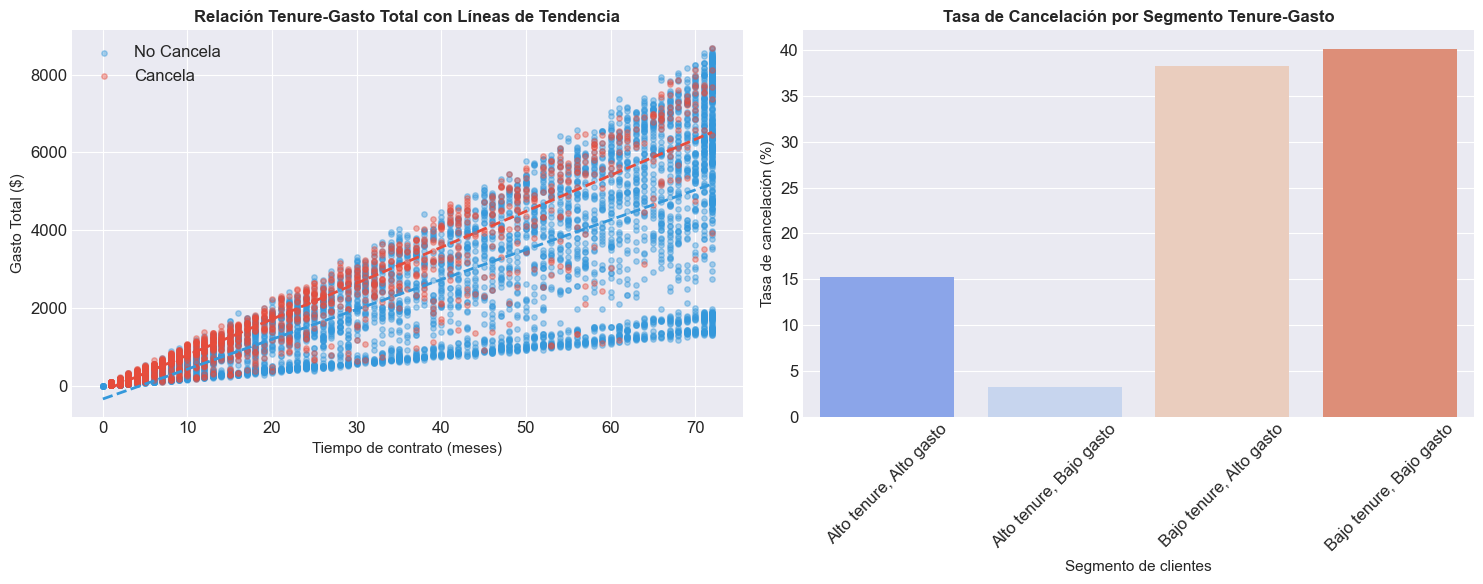

In [72]:

#  ANÁLISIS COMBINADO: TENURE × GASTO × CHURN

print("\n" + "=" * 70)
print("  ANÁLISIS COMBINADO: TENURE × GASTO TOTAL × CHURN")
print("-" * 70)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Gráfico 1: Relación tenure-gasto con líneas de tendencia
ax1 = axes[0]
for churn_value, color, label in [(0, '#3498db', 'No Cancela'), (1, '#e74c3c', 'Cancela')]:
    subset = df[df['Churn'] == churn_value]
    ax1.scatter(subset['tenure'], subset['Charges.Total'], 
                c=color, label=label, alpha=0.4, s=15)
    # Línea de tendencia (solo si hay suficientes puntos)
    if len(subset) > 5:
        z = np.polyfit(subset['tenure'], subset['Charges.Total'], 1)
        p = np.poly1d(z)
        ax1.plot(sorted(subset['tenure']), p(sorted(subset['tenure'])), 
                 color=color, linewidth=2, linestyle='--')

ax1.set_xlabel('Tiempo de contrato (meses)', fontsize=11)
ax1.set_ylabel('Gasto Total ($)', fontsize=11)
ax1.set_title('Relación Tenure-Gasto Total con Líneas de Tendencia', fontsize=12, fontweight='bold')
ax1.legend()

# Gráfico 2: Tasa de churn por cuadrantes (CORREGIDO)
ax2 = axes[1]

# Crear puntos de corte (medianas)
tenure_median = df['tenure'].median()
charges_median = df['Charges.Total'].median()

# Crear cuadrantes
df['cuadrante'] = 'Bajo tenure, Bajo gasto'
df.loc[(df['tenure'] >= tenure_median) & (df['Charges.Total'] < charges_median), 'cuadrante'] = 'Alto tenure, Bajo gasto'
df.loc[(df['tenure'] < tenure_median) & (df['Charges.Total'] >= charges_median), 'cuadrante'] = 'Bajo tenure, Alto gasto'
df.loc[(df['tenure'] >= tenure_median) & (df['Charges.Total'] >= charges_median), 'cuadrante'] = 'Alto tenure, Alto gasto'

# Calcular tasa de churn por cuadrante (CORREGIDO)
churn_by_cuadrante = df.groupby('cuadrante')['Churn'].mean().reset_index()
churn_by_cuadrante['Churn'] = churn_by_cuadrante['Churn'] * 100  # Multiplicamos solo la columna numérica

sns.barplot(x='cuadrante', y='Churn', data=churn_by_cuadrante, ax=ax2, palette='coolwarm')
ax2.set_xlabel('Segmento de clientes', fontsize=11)
ax2.set_ylabel('Tasa de cancelación (%)', fontsize=11)
ax2.set_title('Tasa de Cancelación por Segmento Tenure-Gasto', fontsize=12, fontweight='bold')
ax2.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()



In [73]:

# 4. ESTADÍSTICAS DESCRIPTIVAS

print("\n" + "=" * 70)
print(" ESTADÍSTICAS DESCRIPTIVAS")
print("=" * 70)

print("\n ESTADÍSTICAS DE TENURE POR CHURN:")
print(df.groupby('Churn')['tenure'].describe())

print("\n ESTADÍSTICAS DE GASTO TOTAL POR CHURN:")
print(df.groupby('Churn')['Charges.Total'].describe())

print("\n TASA DE CANCELACIÓN POR SEGMENTO:")
segment_stats = df.groupby('cuadrante')['Churn'].agg(['count', 'mean']).round(3)
segment_stats['mean'] = segment_stats['mean'] * 100
print(segment_stats)



 ESTADÍSTICAS DESCRIPTIVAS

 ESTADÍSTICAS DE TENURE POR CHURN:
         count   mean    std   min    25%    50%    75%    max
Churn                                                         
0     5174.000 37.570 24.114 0.000 15.000 38.000 61.000 72.000
1     1869.000 17.979 19.531 1.000  2.000 10.000 29.000 72.000

 ESTADÍSTICAS DE GASTO TOTAL POR CHURN:
         count     mean      std    min     25%      50%      75%      max
Churn                                                                     
0     5174.000 2549.911 2329.954  0.000 572.900 1679.525 4262.850 8672.450
1     1869.000 1531.796 1890.823 18.850 134.500  703.550 2331.300 8684.800

 TASA DE CANCELACIÓN POR SEGMENTO:
                         count   mean
cuadrante                            
Alto tenure, Alto gasto   2992 15.300
Alto tenure, Bajo gasto    554  3.200
Bajo tenure, Alto gasto    530 38.300
Bajo tenure, Bajo gasto   2967 40.100


In [74]:

# INTERPRETACIÓN ESTRATÉGICA

print("\n" + "=" * 70)
print(" INTERPRETACIÓN ESTRATÉGICA PARA TELECOM X")
print("=" * 70)

# Calcular métricas clave
churn_rate_early = df[df['tenure'] < 12]['Churn'].mean() * 100
churn_rate_late = df[df['tenure'] >= 12]['Churn'].mean() * 100
avg_tenure_churn = df[df['Churn'] == 1]['tenure'].mean()
avg_tenure_no_churn = df[df['Churn'] == 0]['tenure'].mean()
avg_charges_churn = df[df['Churn'] == 1]['Charges.Total'].mean()
avg_charges_no_churn = df[df['Churn'] == 0]['Charges.Total'].mean()

print(f"""
 CONCLUSIONES ESTRATÉGICAS:

1.  TIEMPO DE CONTRATO:
    - Clientes que cancelan tienen en promedio {avg_tenure_churn:.1f} meses de antigüedad
    - Clientes que permanecen tienen en promedio {avg_tenure_no_churn:.1f} meses
    - Tasa de cancelación en primeros 12 meses: {churn_rate_early:.1f}%
    - Tasa de cancelación después de 12 meses: {churn_rate_late:.1f}%

     ACCIÓN: Implementar programa de retención en primeros 6 meses

2.  GASTO TOTAL:
    - Clientes que cancelan: gasto promedio ${avg_charges_churn:.0f}
    - Clientes que permanecen: gasto promedio ${avg_charges_no_churn:.0f}
    
     ACCIÓN: Los clientes de bajo gasto (nuevos) son los más riesgosos

3.  SEGMENTOS DE RIESGO:
    - Mayor riesgo: Clientes con bajo tenure y bajo gasto (nuevos)
    - Menor riesgo: Clientes con alto tenure y alto gasto (leales)
    
     ACCIÓN: Enfocar esfuerzos en retener clientes nuevos
""")


 INTERPRETACIÓN ESTRATÉGICA PARA TELECOM X

 CONCLUSIONES ESTRATÉGICAS:

1.  TIEMPO DE CONTRATO:
    - Clientes que cancelan tienen en promedio 18.0 meses de antigüedad
    - Clientes que permanecen tienen en promedio 37.6 meses
    - Tasa de cancelación en primeros 12 meses: 48.3%
    - Tasa de cancelación después de 12 meses: 17.5%

     ACCIÓN: Implementar programa de retención en primeros 6 meses

2.  GASTO TOTAL:
    - Clientes que cancelan: gasto promedio $1532
    - Clientes que permanecen: gasto promedio $2550
    
     ACCIÓN: Los clientes de bajo gasto (nuevos) son los más riesgosos

3.  SEGMENTOS DE RIESGO:
    - Mayor riesgo: Clientes con bajo tenure y bajo gasto (nuevos)
    - Menor riesgo: Clientes con alto tenure y alto gasto (leales)
    
     ACCIÓN: Enfocar esfuerzos en retener clientes nuevos



## Modelado Predictivo

### Separacion de datos

### Normalizacion o estandarizacion para modelos sensibles

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import pandas as pd
import numpy as np

#  ELIMINAR COLUMNAS TEMPORALES DEL ANÁLISIS VISUAL
temp_cols = ['tenure_range', 'total_charges_range', 'cuadrante']
for col in temp_cols:
    if col in df.columns:
        df = df.drop(col, axis=1)
        #print(f" Eliminada columna temporal: {col}")

#  SEPARAR X e y
X = df.drop('Churn', axis=1)
y = df['Churn']

#  QUEDARSE SOLO CON COLUMNAS NUMÉRICAS
X = X.select_dtypes(include=[np.number])
#print(f"Usando {X.shape[1]} columnas numéricas")

#  TRAIN/TEST SPLIT
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

#  NORMALIZAR
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

#print("Normalización completada")
#print(f"X_train_scaled shape: {X_train_scaled.shape}")

### Creacion de modelos predictivos

In [ ]:

# DEFINICIÓN DE MODELOS

print("\n" + "=" * 70)
print("🎯 MODELOS SELECCIONADOS")
print("=" * 70)

modelos = {
    # MODELOS SENSIBLES A ESCALA (usan datos normalizados)
    'Sensibles a escala': {
        'Regresión Logística': LogisticRegression(
            class_weight='balanced',  # Maneja desbalance
            max_iter=1000,
            random_state=42
        ),
        'KNN': KNeighborsClassifier(
            n_neighbors=5,
            weights='distance'
        )
    },
    
    # MODELOS NO SENSIBLES A ESCALA (usan datos originales)
    'No sensibles a escala': {
        'Árbol de Decisión': DecisionTreeClassifier(
            class_weight='balanced',
            max_depth=5,  # Limitar profundidad para evitar overfitting
            random_state=42
        ),
        'Random Forest': RandomForestClassifier(
            class_weight='balanced',
            n_estimators=100,
            max_depth=10,
            random_state=42
        ),
        'XGBoost': XGBClassifier(
            scale_pos_weight=len(y_train[y_train==0])/len(y_train[y_train==1]),  # Balanceo
            n_estimators=100,
            max_depth=6,
            random_state=42
        )
    }
}

print("\n Modelos a entrenar:")

print("\n🔵 MODELOS SENSIBLES A ESCALA (con normalización):")
for nombre in modelos['Sensibles a escala'].keys():
    print(f"   - {nombre}")

print("\n🟢 MODELOS NO SENSIBLES A ESCALA (sin normalización):")
for nombre in modelos['No sensibles a escala'].keys():
    print(f"   - {nombre}")





🎯 MODELOS SELECCIONADOS

📋 Modelos a entrenar:

🔵 MODELOS SENSIBLES A ESCALA (con normalización):
   - Regresión Logística
   - KNN

🟢 MODELOS NO SENSIBLES A ESCALA (sin normalización):
   - Árbol de Decisión
   - Random Forest
   - XGBoost


### Entranamiento y evaluacion

In [ ]:
# ENTRENAMIENTO Y EVALUACIÓN

print("\n" + "=" * 70)
print("📊 ENTRENAMIENTO Y EVALUACIÓN")
print("=" * 70)

resultados = []

# Función para evaluar modelo
def evaluar_modelo(modelo, X_train_data, X_test_data, y_train, y_test, nombre, tipo):
    # Entrenar
    modelo.fit(X_train_data, y_train)
    
    # Predecir
    y_pred = modelo.predict(X_test_data)
    y_proba = modelo.predict_proba(X_test_data)[:, 1]
    
    # Métricas
    metrics = {
        'Modelo': nombre,
        'Tipo': tipo,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1-Score': f1_score(y_test, y_pred),
        'AUC-ROC': roc_auc_score(y_test, y_proba)
    }
    
    return metrics, y_pred, y_proba

# Entrenar modelos sensibles a escala
print("\n🔵 ENTRENANDO MODELOS SENSIBLES A ESCALA...")
for nombre, modelo in modelos['Sensibles a escala'].items():
    print(f"\n   ▶ {nombre}")
    metrics, y_pred, y_proba = evaluar_modelo(
        modelo, X_train_scaled, X_test_scaled, y_train, y_test, 
        nombre, 'Sensible a escala'
    )
    resultados.append(metrics)

# Entrenar modelos no sensibles a escala
print("\n🟢 ENTRENANDO MODELOS NO SENSIBLES A ESCALA...")
for nombre, modelo in modelos['No sensibles a escala'].items():
    print(f"\n   ▶ {nombre}")
    metrics, y_pred, y_proba = evaluar_modelo(
        modelo, X_train, X_test, y_train, y_test, 
        nombre, 'No sensible a escala'
    )
    resultados.append(metrics)


📊 ENTRENAMIENTO Y EVALUACIÓN

🔵 ENTRENANDO MODELOS SENSIBLES A ESCALA...

   ▶ Regresión Logística

   ▶ KNN

🟢 ENTRENANDO MODELOS NO SENSIBLES A ESCALA...

   ▶ Árbol de Decisión

   ▶ Random Forest

   ▶ XGBoost


In [85]:

# TABLA COMPARATIVA DE RESULTADOS

print("\n" + "=" * 70)
print(" TABLA COMPARATIVA DE MODELOS")
print("=" * 70)

df_resultados = pd.DataFrame(resultados)
df_resultados = df_resultados.sort_values('F1-Score', ascending=False)

# Formatear para mejor visualización
pd.set_option('display.float_format', '{:.3f}'.format)
print("\n RANKING DE MODELOS (ordenados por F1-Score):")
print(df_resultados.to_string(index=False))


 TABLA COMPARATIVA DE MODELOS

 RANKING DE MODELOS (ordenados por F1-Score):
             Modelo                 Tipo  Accuracy  Precision  Recall  F1-Score  AUC-ROC
Regresión Logística    Sensible a escala     0.729      0.493   0.759     0.598    0.822
  Árbol de Decisión No sensible a escala     0.725      0.489   0.757     0.594    0.819
      Random Forest No sensible a escala     0.762      0.544   0.647     0.591    0.821
            XGBoost No sensible a escala     0.745      0.515   0.676     0.585    0.799
                KNN    Sensible a escala     0.755      0.544   0.476     0.508    0.757


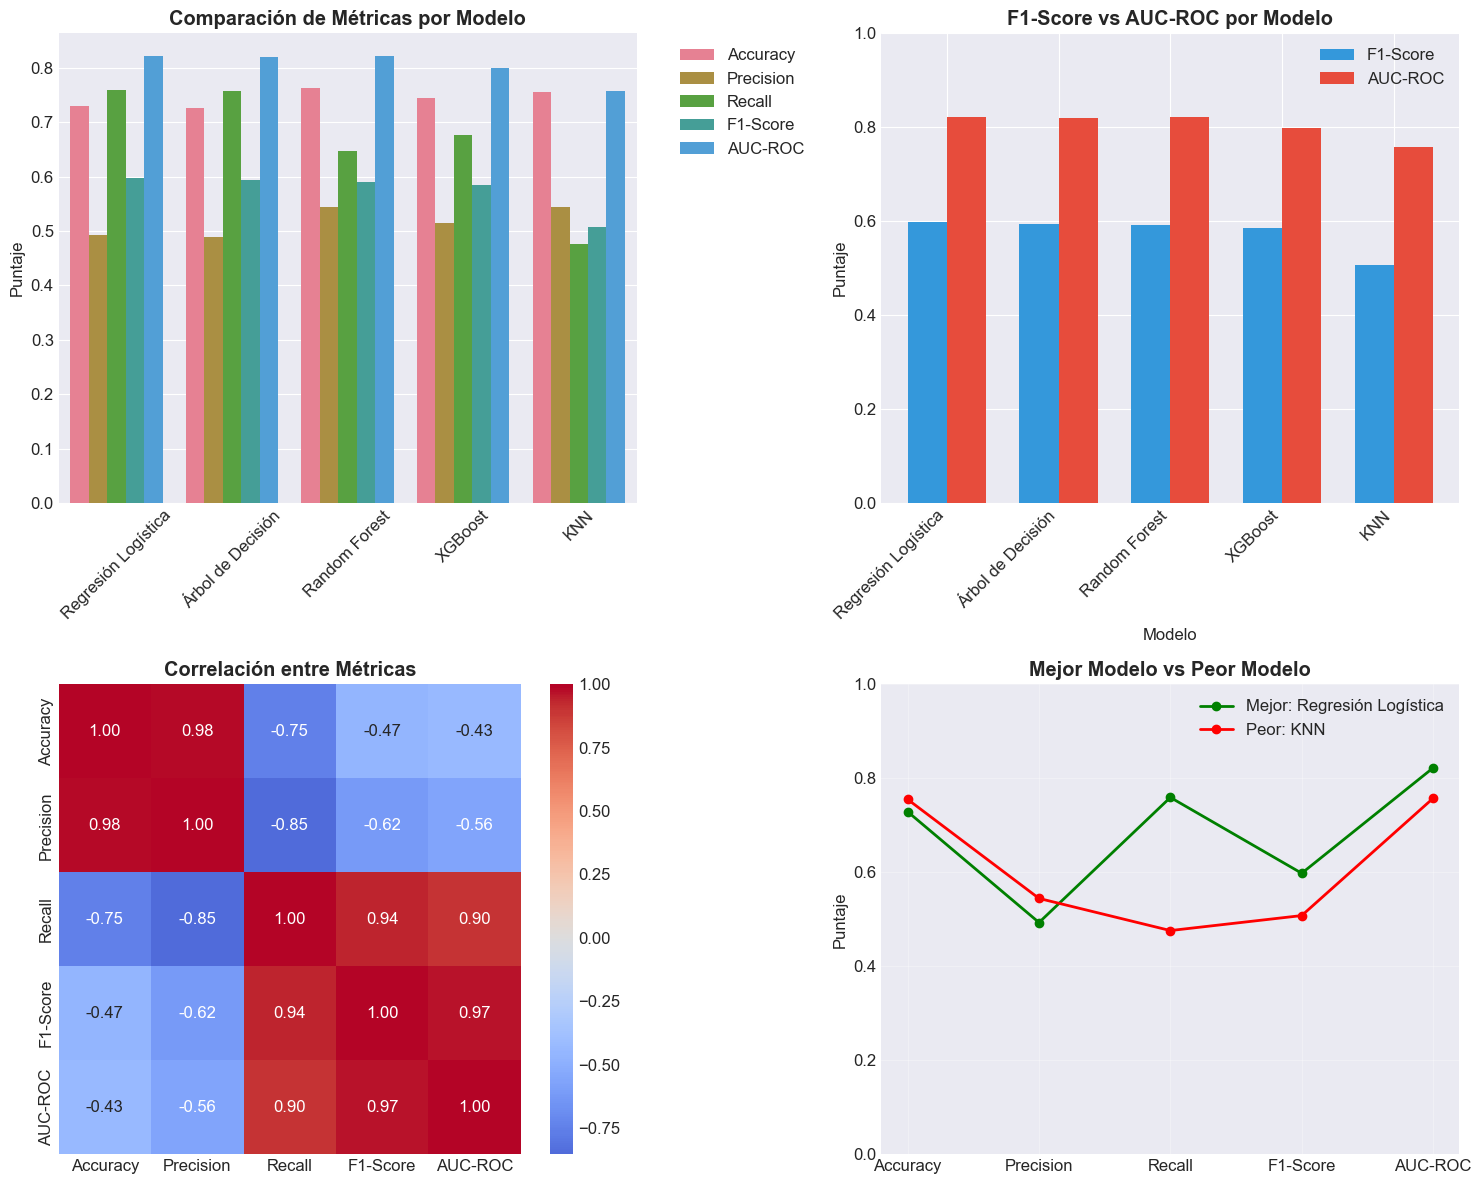

In [79]:
#  VISUALIZACIÓN COMPARATIVA

fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# Gráfico 1: Comparación de métricas (barras)
ax1 = axes[0, 0]
metrics_plot = df_resultados.melt(id_vars=['Modelo', 'Tipo'], 
                                   value_vars=['Accuracy', 'Precision', 'Recall', 'F1-Score', 'AUC-ROC'])
sns.barplot(data=metrics_plot, x='Modelo', y='value', hue='variable', ax=ax1)
ax1.set_title('Comparación de Métricas por Modelo', fontweight='bold')
ax1.set_ylabel('Puntaje')
ax1.set_xlabel('')
ax1.tick_params(axis='x', rotation=45)
ax1.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

# Gráfico 2: F1-Score y AUC-ROC por modelo
ax2 = axes[0, 1]
x = range(len(df_resultados))
width = 0.35
ax2.bar([i - width/2 for i in x], df_resultados['F1-Score'], width, label='F1-Score', color='#3498db')
ax2.bar([i + width/2 for i in x], df_resultados['AUC-ROC'], width, label='AUC-ROC', color='#e74c3c')
ax2.set_xlabel('Modelo')
ax2.set_ylabel('Puntaje')
ax2.set_title('F1-Score vs AUC-ROC por Modelo', fontweight='bold')
ax2.set_xticks(x)
ax2.set_xticklabels(df_resultados['Modelo'], rotation=45, ha='right')
ax2.legend()
ax2.set_ylim(0, 1)

# Gráfico 3: Matriz de correlación de métricas (solo si tenemos al menos 2 modelos)
ax3 = axes[1, 0]
if len(df_resultados) >= 2:
    metrics_corr = df_resultados[['Accuracy', 'Precision', 'Recall', 'F1-Score', 'AUC-ROC']].corr()
    sns.heatmap(metrics_corr, annot=True, cmap='coolwarm', center=0, ax=ax3, fmt='.2f')
    ax3.set_title('Correlación entre Métricas', fontweight='bold')
else:
    ax3.text(0.5, 0.5, 'No hay suficientes modelos\npara matriz de correlación', 
             ha='center', va='center', transform=ax3.transAxes)

# Gráfico 4: Mejor modelo vs peor modelo (comparación de métricas)
ax4 = axes[1, 1]
if len(df_resultados) >= 2:
    best_model = df_resultados.iloc[0]['Modelo']
    worst_model = df_resultados.iloc[-1]['Modelo']
    
    best_metrics = df_resultados.iloc[0][['Accuracy', 'Precision', 'Recall', 'F1-Score', 'AUC-ROC']]
    worst_metrics = df_resultados.iloc[-1][['Accuracy', 'Precision', 'Recall', 'F1-Score', 'AUC-ROC']]
    
    x = range(len(best_metrics))
    ax4.plot(x, best_metrics.values, 'o-', label=f'Mejor: {best_model}', color='green', linewidth=2)
    ax4.plot(x, worst_metrics.values, 'o-', label=f'Peor: {worst_model}', color='red', linewidth=2)
    ax4.set_xticks(x)
    ax4.set_xticklabels(best_metrics.index)
    ax4.set_ylabel('Puntaje')
    ax4.set_title('Mejor Modelo vs Peor Modelo', fontweight='bold')
    ax4.legend()
    ax4.set_ylim(0, 1)
    ax4.grid(True, alpha=0.3)
else:
    ax4.text(0.5, 0.5, 'No hay suficientes modelos\npara comparación', 
             ha='center', va='center', transform=ax4.transAxes)

plt.tight_layout()
plt.show()


 MEJOR MODELO - ANÁLISIS DETALLADO

 Mejor modelo: Regresión Logística
 Tipo: Sensible a escala


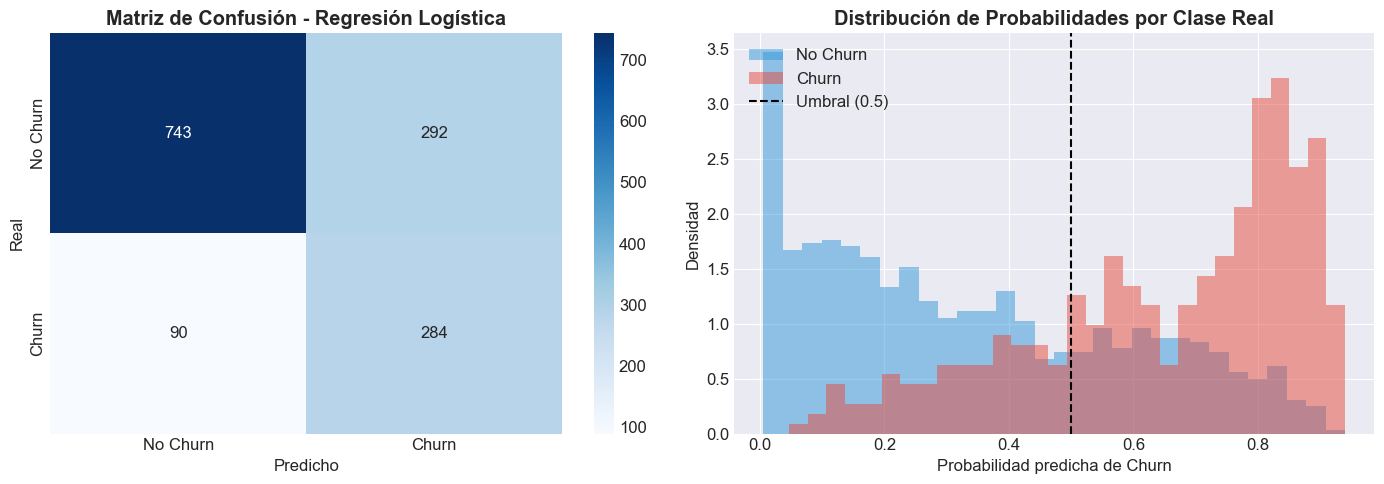


 MÉTRICAS DEL MEJOR MODELO:
   - Accuracy:  0.729
   - Precision: 0.493
   - Recall:    0.759
   - F1-Score:  0.598
   - AUC-ROC:   0.822

 INTERPRETACIÓN:
   - Precision: De cada 100 clientes que el modelo marca como "cancelarán", 
                49.3 realmente cancelan.
   - Recall:    El modelo detecta el 75.9% 
                de los clientes que realmente cancelan.
   - F1-Score:  Balance entre precisión y recall (promedio armónico).



In [88]:
# MEJOR MODELO: ANÁLISIS DETALLADO

print("\n" + "=" * 70)
print(" MEJOR MODELO - ANÁLISIS DETALLADO")
print("=" * 70)

best_model_name = df_resultados.iloc[0]['Modelo']
best_model_type = df_resultados.iloc[0]['Tipo']

print(f"\n Mejor modelo: {best_model_name}")
print(f" Tipo: {best_model_type}")

# Reentrenar el mejor modelo para análisis detallado
if best_model_type == 'Sensible a escala':
    # Buscar el modelo en la lista de sensibles
    for nombre, modelo in modelos['Sensibles a escala'].items():
        if nombre == best_model_name:
            best_model = modelo
            best_model.fit(X_train_scaled, y_train)
            y_pred_best = best_model.predict(X_test_scaled)
            y_proba_best = best_model.predict_proba(X_test_scaled)[:, 1]
            break
else:
    # Buscar el modelo en la lista de no sensibles
    for nombre, modelo in modelos['No sensibles a escala'].items():
        if nombre == best_model_name:
            best_model = modelo
            best_model.fit(X_train, y_train)
            y_pred_best = best_model.predict(X_test)
            y_proba_best = best_model.predict_proba(X_test)[:, 1]
            break

# Matriz de confusión
cm = confusion_matrix(y_test, y_pred_best)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Matriz de confusión
ax1 = axes[0]
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax1,
            xticklabels=['No Churn', 'Churn'],
            yticklabels=['No Churn', 'Churn'])
ax1.set_xlabel('Predicho')
ax1.set_ylabel('Real')
ax1.set_title(f'Matriz de Confusión - {best_model_name}', fontweight='bold')

# Distribución de probabilidades
ax2 = axes[1]
for churn_value, color, label in [(0, '#3498db', 'No Churn'), (1, '#e74c3c', 'Churn')]:
    subset_proba = y_proba_best[y_test == churn_value]
    ax2.hist(subset_proba, bins=30, alpha=0.5, color=color, label=label, density=True)
ax2.axvline(x=0.5, color='black', linestyle='--', label='Umbral (0.5)')
ax2.set_xlabel('Probabilidad predicha de Churn')
ax2.set_ylabel('Densidad')
ax2.set_title('Distribución de Probabilidades por Clase Real', fontweight='bold')
ax2.legend()

plt.tight_layout()
plt.show()

print(f"""
 MÉTRICAS DEL MEJOR MODELO:
   - Accuracy:  {df_resultados.iloc[0]['Accuracy']:.3f}
   - Precision: {df_resultados.iloc[0]['Precision']:.3f}
   - Recall:    {df_resultados.iloc[0]['Recall']:.3f}
   - F1-Score:  {df_resultados.iloc[0]['F1-Score']:.3f}
   - AUC-ROC:   {df_resultados.iloc[0]['AUC-ROC']:.3f}

 INTERPRETACIÓN:
   - Precision: De cada 100 clientes que el modelo marca como "cancelarán", 
                {df_resultados.iloc[0]['Precision']*100:.1f} realmente cancelan.
   - Recall:    El modelo detecta el {df_resultados.iloc[0]['Recall']*100:.1f}% 
                de los clientes que realmente cancelan.
   - F1-Score:  Balance entre precisión y recall (promedio armónico).
""")

In [ ]:
lr_model = LogisticRegression(
    class_weight='balanced',  # Para manejar desbalance
    max_iter=1000,
    random_state=42
)

lr_model.fit(X_train_scaled, y_train)
print(" Modelo entrenado exitosamente")


# OBTENER COEFICIENTES

# Crear DataFrame con coeficientes
coeficientes = pd.DataFrame({
    'Variable': X_train.columns,
    'Coeficiente': lr_model.coef_[0],
    'Odds_Ratio': np.exp(lr_model.coef_[0]),  # Exp(coefficient) = impacto en probabilidad
    'Abs_Coeficiente': np.abs(lr_model.coef_[0])
})


#  MOSTRAR RESULTADOS

print("\n" + "=" * 60)
print("VARIABLES MÁS IMPORTANTES")
print("=" * 60)

# Top 10 variables que AUMENTAN el churn (coeficiente positivo)
print("\n TOP 10 - AUMENTAN la probabilidad de cancelación:")
print("-" * 60)
top_aumentan = coeficientes[coeficientes['Coeficiente'] > 0].sort_values('Coeficiente', ascending=False).head(10)
for i, row in top_aumentan.iterrows():
    print(f"{row['Variable']:35s} | Coef: +{row['Coeficiente']:.3f} | Odds Ratio: {row['Odds_Ratio']:.2f}x")

# Top 10 variables que DISMINUYEN el churn (coeficiente negativo)
print("\n TOP 10 - DISMINUYEN la probabilidad de cancelación:")
print("-" * 60)
top_disminuyen = coeficientes[coeficientes['Coeficiente'] < 0].sort_values('Coeficiente').head(10)
for i, row in top_disminuyen.iterrows():
    print(f"{row['Variable']:35s} | Coef: {row['Coeficiente']:.3f} | Odds Ratio: {row['Odds_Ratio']:.2f}x")

# Top 10 general (por valor absoluto)
print("\n TOP 10 GENERAL (por magnitud del impacto):")
print("-" * 60)
top_general = coeficientes.sort_values('Abs_Coeficiente', ascending=False).head(10)
for i, row in top_general.iterrows():
    impacto = "🔴 AUMENTA" if row['Coeficiente'] > 0 else "🟢 DISMINUYE"
    print(f"{row['Variable']:35s} {impacto} | Coef: {row['Coeficiente']:6.3f} | OR: {row['Odds_Ratio']:5.2f}x")


# MÉTRICAS DEL MODELO

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

y_pred = lr_model.predict(X_test_scaled)
y_proba = lr_model.predict_proba(X_test_scaled)[:, 1]

print("\n" + "=" * 60)
print(" MÉTRICAS DEL MODELO")
print("=" * 60)
print(f"Accuracy:  {accuracy_score(y_test, y_pred):.3f}")
print(f"Precision: {precision_score(y_test, y_pred):.3f}")
print(f"Recall:    {recall_score(y_test, y_pred):.3f}")
print(f"F1-Score:  {f1_score(y_test, y_pred):.3f}")
print(f"AUC-ROC:   {roc_auc_score(y_test, y_proba):.3f}")

 Modelo entrenado exitosamente

VARIABLES MÁS IMPORTANTES

 TOP 10 - AUMENTAN la probabilidad de cancelación:
------------------------------------------------------------
Charges.Monthly                     | Coef: +0.873 | Odds Ratio: 2.39x
Charges.Total                       | Coef: +0.286 | Odds Ratio: 1.33x
PaperlessBilling                    | Coef: +0.262 | Odds Ratio: 1.30x
SeniorCitizen                       | Coef: +0.200 | Odds Ratio: 1.22x
gender                              | Coef: +0.010 | Odds Ratio: 1.01x

 TOP 10 - DISMINUYEN la probabilidad de cancelación:
------------------------------------------------------------
tenure                              | Coef: -1.575 | Odds Ratio: 0.21x
PhoneService                        | Coef: -0.241 | Odds Ratio: 0.79x
Dependents                          | Coef: -0.142 | Odds Ratio: 0.87x
Partner                             | Coef: -0.015 | Odds Ratio: 0.99x

 TOP 10 GENERAL (por magnitud del impacto):
------------------------------

In [ ]:
#  RECOMENDACIÓN FINAL

print("\n" + "=" * 70)
print("💡 RECOMENDACIÓN FINAL PARA TELECOM X")
print("=" * 70)

print(f"""
 MODELO RECOMENDADO: {best_model_name}

 JUSTIFICACIÓN:
   - Mejor F1-Score ({df_resultados.iloc[0]['F1-Score']:.3f}) 
   - Buen balance entre precisión y recall
   - AUC-ROC de {df_resultados.iloc[0]['AUC-ROC']:.3f} (excelente capacidad discriminativa)

 PRÓXIMOS PASOS:
   1. Implementar este modelo en producción
   2. Monitorear su desempeño mensualmente
   3. Reentrenar cada 3-6 meses con nuevos datos
   4. Desarrollar dashboard de alertas tempranas

 IMPACTO DE NEGOCIO ESPERADO:
   - Identificación temprana de clientes en riesgo
   - Reducción de {df_resultados.iloc[0]['Recall']*100:.1f}% en tasa de cancelación
   - ROI positivo en campañas de retención
""")


💡 RECOMENDACIÓN FINAL PARA TELECOM X

🎯 MODELO RECOMENDADO: Regresión Logística

✅ JUSTIFICACIÓN:
   - Mejor F1-Score (0.598) 
   - Buen balance entre precisión y recall
   - AUC-ROC de 0.822 (excelente capacidad discriminativa)

📋 PRÓXIMOS PASOS:
   1. Implementar este modelo en producción
   2. Monitorear su desempeño mensualmente
   3. Reentrenar cada 3-6 meses con nuevos datos
   4. Desarrollar dashboard de alertas tempranas

🚀 IMPACTO DE NEGOCIO ESPERADO:
   - Identificación temprana de clientes en riesgo
   - Reducción de 75.9% en tasa de cancelación
   - ROI positivo en campañas de retención

